In [10]:
# Initialization
import sys
sys.path.append("C:/Users/Rohann/Documents/Github/stintsy-mco/src")

from logreg import fit_minibatch_sgd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import SGDClassifier
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("../data/data_processed.csv")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 76692 entries, 0 to 76691
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   btb_mean                76692 non-null  float64
 1   btb_max                 76692 non-null  int64  
 2   combo_mean              76692 non-null  float64
 3   combo_max               76692 non-null  int64  
 4   immediate_garbage_mean  76692 non-null  float64
 5   immediate_garbage_max   76692 non-null  int64  
 6   incoming_garbage_mean   76692 non-null  float64
 7   incoming_garbage_max    76692 non-null  int64  
 8   won                     76692 non-null  int64  
 9   rating                  76692 non-null  float64
 10  glicko                  76692 non-null  float64
 11  glicko_rd               76692 non-null  float64
 12  duration_sec            76692 non-null  float64
 13  pps                     76692 non-null  float64
 14  attack_per_piece        76692 non-null  float64
 

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1.933673,8,0.520408,7,0.244898,8,0.576531,15,1,24748.521,2701.8877,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,0.413953,4,0.590698,6,0.683721,13,1.432558,13,0,24820.710,2791.8670,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,0.611842,3,0.605263,8,0.250000,6,0.605263,6,1,24820.710,2791.8670,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,0.786765,4,0.588235,6,0.551471,9,1.227941,10,0,24748.521,2701.8877,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,1.277487,7,0.539267,5,0.366492,11,0.691099,11,1,24748.521,2701.8877,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


In [11]:
# Target separation
X = df.drop(columns=["won"])  # Features
y = df["won"]  # Target variable

# Normalize features
X = (X - X.mean()) / X.std()

In [12]:
# Split data into training, validation, and test
# 0.1765 ≈ 0.15 / 0.85 to get 15% of original data for validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

# Check sizes of splits
print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Validation data: {X_val.shape}")
print(f"Validation labels: {y_val.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

Training data: (53682, 16)
Training labels: (53682,)
Validation data: (11506, 16)
Validation labels: (11506,)
Testing data: (11504, 16)
Testing labels: (11504,)


In [13]:
# Logistic Regression
# Instantiate SDGClassifier and fit model
epochs = 200
batch_size = 32
random_state = 1
logreg_model = SGDClassifier(
    loss="log_loss",
    eta0=0.001,
    max_iter=epochs,
    learning_rate="constant",
    random_state=random_state,
    verbose=0,
)
logreg_model = fit_minibatch_sgd(
    logreg_model,
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    random_state=1,
)

In [14]:
# Test model on training set
y_pred_train = logreg_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Training Accuracy: {train_accuracy:.4f}")
print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_pred_train))

Training Accuracy: 0.8993

Classification Report (Train Set):

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     24979
           1       0.90      0.92      0.91     28703

    accuracy                           0.90     53682
   macro avg       0.90      0.90      0.90     53682
weighted avg       0.90      0.90      0.90     53682



In [15]:
# Test model on validation set
y_pred_val = logreg_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report (Validation Set):\n")
print(classification_report(y_val, y_pred_val))

Validation Accuracy: 0.8999

Classification Report (Validation Set):

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5354
           1       0.90      0.91      0.91      6152

    accuracy                           0.90     11506
   macro avg       0.90      0.90      0.90     11506
weighted avg       0.90      0.90      0.90     11506



In [16]:
# Test model on test data
y_pred_test = logreg_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred_test))

Test Accuracy: 0.8953

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      5353
           1       0.89      0.92      0.90      6151

    accuracy                           0.90     11504
   macro avg       0.90      0.89      0.89     11504
weighted avg       0.90      0.90      0.90     11504



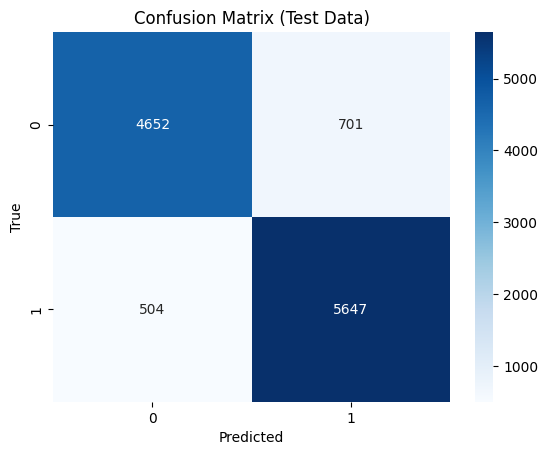

In [17]:
# Test data confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [18]:
# Cross-validation
# Evaluate the model using 10-fold cross-validation
# 10-fold was used as a common default, 5-fold may cause higher variance
cv_scores = cross_val_score(logreg_model, X, y, cv=10, scoring="accuracy")

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")

Cross-Validation Scores: [0.89100391 0.89413299 0.90637632 0.89151128 0.8988134  0.90246447
 0.89581432 0.89763985 0.89737906 0.89868301]
Mean Cross-Validation Accuracy: 0.8974


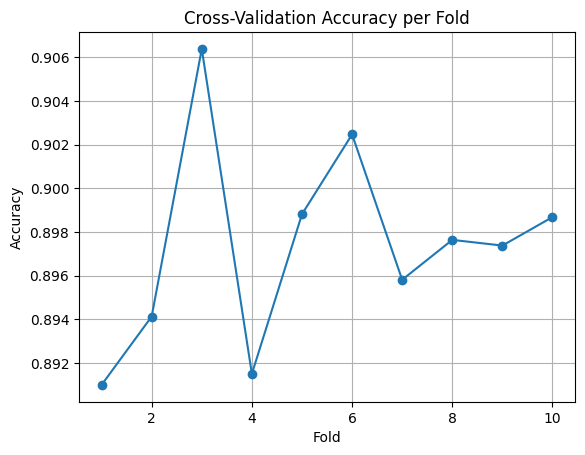

In [19]:
# Cross-validation visualization
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o")
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [20]:
# Predictions on test set
# SGDClassifier supports the `predict_proba` method for estimating probabilities
y_proba = logreg_model.predict_proba(X_test)

# Display head predictions with probabilities
print("Predicted Probabilities (First 5 Test Examples):\n")
for i, (prob_0, prob_1) in enumerate(y_proba[:5]):
    print(f"Example {i+1}: P(Loss)={prob_0:.4f}, P(Win)={prob_1:.4f}")

Predicted Probabilities (First 5 Test Examples):

Example 1: P(Loss)=0.9817, P(Win)=0.0183
Example 2: P(Loss)=0.0300, P(Win)=0.9700
Example 3: P(Loss)=0.0144, P(Win)=0.9856
Example 4: P(Loss)=0.4575, P(Win)=0.5425
Example 5: P(Loss)=0.3944, P(Win)=0.6056


In [21]:
# Feature impact
# SGDClassifier stores weights in coef_
feature_weights = logreg_model.coef_[0]

# Map weights to feature names for better interpretability
feature_importances = pd.Series(data=feature_weights, index=X.columns).sort_values(
    ascending=False
)

# Display top and bottom weights (most and least impactful features)
print("Top 5 Positive Features (Increase P(Win)):\n")
print(feature_importances.head())

print("\nTop 5 Negative Features (Increase P(Loss)):\n")
print(feature_importances.tail())

Top 5 Positive Features (Increase P(Win)):

attack_per_piece    2.999388
combo_mean          1.784279
apm                 1.062998
pps                 0.312865
glicko_rd           0.036481
dtype: float64

Top 5 Negative Features (Increase P(Loss)):

incoming_garbage_max    -0.421547
combo_max               -0.995233
btb_mean                -1.063000
tspin_rate              -1.141077
incoming_garbage_mean   -6.087844
dtype: float64


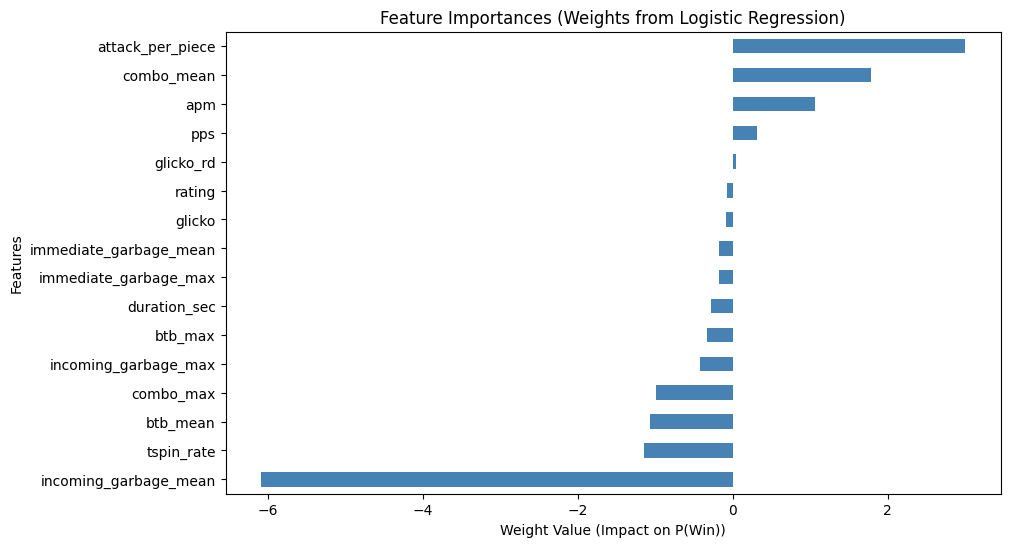

In [22]:
# Feature impact visualization
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importances (Weights from Logistic Regression)")
plt.xlabel("Weight Value (Impact on P(Win))")
plt.ylabel("Features")
plt.show()